# Turning Bullish
## Objective
* Your task is to calculate the 50-day and 200-day moving averages based on the closing price, and identify every “Golden Cross” moment – when the short-term average (50-day) crosses from below to above the long-term average (200-day) – signaling a potential bull market.

[Source](https://mavenanalytics.io/data-drills/turning-bullish)

In [1]:
import pandas as pd
ventana_50 = 50
ventana_200 = 200
file = pd.read_csv("SPY_close_price_5Y.csv", delimiter=",", parse_dates=['Date'])

In [2]:
file['fwd_avg_50'] = file['Close'].rolling(window=ventana_50, min_periods=50).mean()
file['fwd_avg_200'] = file['Close'].rolling(window=ventana_200, min_periods=200).mean()
file['GoldenCross'] = ((file['fwd_avg_50'] > file['fwd_avg_200']) & (file['fwd_avg_50'].shift(1) <= file['fwd_avg_200'].shift(1))).astype(int)

In [3]:
file.query("GoldenCross==1")

,Date,Close,fwd_avg_50,fwd_avg_200,GoldenCross
566,2023-02-02,416.78,394.3504,394.25025,1
1169,2025-07-01,617.65,583.0978,582.04155,1


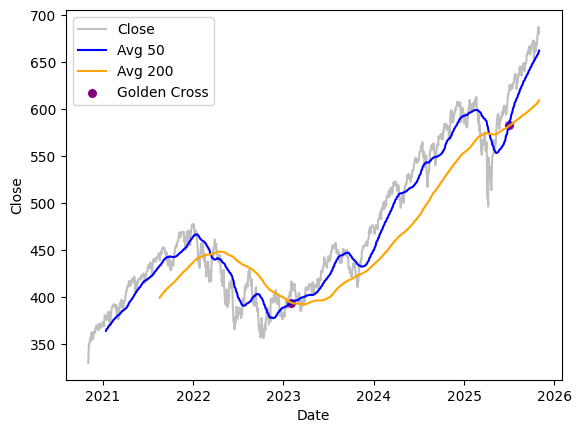

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=file, x="Date", y="Close", label="Close", color="gray", alpha=0.5)
sns.lineplot(data=file, x="Date", y="fwd_avg_50", label="Avg 50", color="blue")
sns.lineplot(data=file, x="Date", y="fwd_avg_200", label="Avg 200", color="orange")

cruces = file.query("GoldenCross==1")

# Añadimos los puntos sobre el gráfico
sns.scatterplot(data=cruces, x="Date", y="fwd_avg_50", 
                color="purple", s=50, marker="o", label="Golden Cross")
plt.legend()
plt.show()

In [ ]:
file = file.assign(
        FwdAvg50= lambda d: d.Close.rolling(window=50, min_periods=50).mean(),
        FwdAvg200 =lambda d: d.Close.rolling(window=200, min_periods=200).mean(),
        GoldenCross = lambda d: ((d.FwdAvg50 > d.FwdAvg200) & (d.FwdAvg50.shift(1) <= d.FwdAvg200.shift(1))).astype(int) 
        )
file.query("GoldenCross==1")

file

,Date,Close,fwd_avg_50,fwd_avg_200,GoldenCross,FwdAvg50,FwdAvg200
566,2023-02-02,416.78,394.3504,394.25025,1,394.3504,394.25025
1169,2025-07-01,617.65,583.0978,582.04155,1,583.0978,582.04155
